## Program 4 Algorithims - Benchmarking Heaps
#### By: Viannys Colon, Madison Mina, and David Salzman
### Introduction
In this project we are implementing three versions of Heapify operation. Heapify operation takes an array in and outputs a heap. The output type is still an array but it is a heap version so children are found later in the array than the parents.
### Description
The first method is the typical built in heapify method - classic method: Add elements one at a time at the root of the tree and bubble them down the tree.

The second method bubbles down by children: Add element one at a time at the root of tree and bubbles down by stopping when element is greater than children.

The third method bubbles down then up: Add element one at a time at the root of tree bubble it all the way down. Then bubble up until element is smaller than its parent.

We will benchmark each method to see which version is the fastest at heapifying an array. The tests will be done with 3 different datasets as detailed in Approach Section.

### Approach
The benchmarking will be done using 3 different datasets.

- increasing - sorted array
- decreasing - reverse sorted
- random - shuffled

Each dataset will be sorted with each of the different methods. They will be compared using runtime of when a method completed the operation. In addition it may also be benefical to test with different size arrays (one small array, one medium array, one big array) to see how much the number of elements impact the efficency of the methods.

### Source Code & Function Explanations

In [1]:
def heapify_method1(arr):
    """Build a max-heap by inserting elements one at a time using sift-up.

    This method appends each element to an internal heap list and performs a
    sift-up (bubble-up) operation to restore the heap property after every
    insertion.

    Time complexity: O(n log n) in the worst case because each of the n
    insertions may require O(log n) swaps to move the element up the tree.
    Space: O(1) additional (returns a new list containing the heap).
    """
    h = []
    def sift_up(h, i):
        while i > 0:
            p = (i - 1) // 2
            if h[i] > h[p]:
                h[i], h[p] = h[p], h[i]
                i = p
            else:
                break
    for x in arr:
        h.append(x)
        sift_up(h, len(h) - 1)
    return h

In [2]:
def heapify_method2(arr):
    """Bottom-up (Floyd) heapify: transform the array into a max-heap in-place.

    This method starts from the last non-leaf node and sifts each node down
    (bubble-down by children) to restore the heap property. It operates on a copy
    of the input and runs in linear time on average.

    Time complexity: O(n).
    Space: O(1) additional (works in-place on a copy).
    """
    h = arr.copy()
    n = len(h)
    def sift_down(h, i, n):
        while True:
            left = 2 * i + 1
            right = left + 1
            largest = i
            if left < n and h[left] > h[largest]:
                largest = left
            if right < n and h[right] > h[largest]:
                largest = right
            if largest == i:
                break
            h[i], h[largest] = h[largest], h[i]
            i = largest
    for i in range((n // 2) - 1, -1, -1):
        sift_down(h, i, n)
    return h

In [3]:
def heapify_method3(arr):
    """Hybrid: insert each element at the root, bubble it down fully, then bubble up.

    For each new element we append it to the heap list and swap it into the root
    position. We then bubble it down (following larger children) until it reaches
    a leaf, and finally bubble it up as needed to fix any violation with its parent.

    This demonstrates the 'bubble down then up' strategy. It is generally less
    efficient than the bottom-up method and typically runs in O(n log n) worst case.

    Time complexity: O(n log n) worst-case.
    Space: O(1) additional (returns a new list).
    """
    h = []
    def sift_down_from(h, i):
        n = len(h)
        while True:
            left = 2 * i + 1
            right = left + 1
            largest = i
            if left < n and h[left] > h[largest]:
                largest = left
            if right < n and h[right] > h[largest]:
                largest = right
            if largest == i:
                break
            h[i], h[largest] = h[largest], h[i]
            i = largest
        return i
    def sift_up_from(h, i):
        while i > 0:
            p = (i - 1) // 2
            if h[i] > h[p]:
                h[i], h[p] = h[p], h[i]
                i = p
            else:
                break
    for x in arr:
        h.append(x)
        if len(h) > 1:
            # place new element at root, then bubble down and up
            h[0], h[-1] = h[-1], h[0]
            idx = sift_down_from(h, 0)
            sift_up_from(h, idx)
    return h

### Benchmark Parameters
The benchmarks were conducted using three types of input data: random arrays, sorted arrays, and reverse-sorted arrays. These help evaluate how input order affects the performance of different heap approaches/methods. Each dataset was generated for input sizes ranging from 1,000 to 50,000 elements, allowing us to observe how runtime scales as the problem size increases. To ensure reliable results, each experiment was repeated five times, and the average runtime was recorded.

In [4]:
import os
import time
import random
import csv
import pandas as pd

SIZES = [1000, 2000, 5000, 10000, 20000, 50000]
TRIALS = 5
INPUT_TYPES = ['random', 'sorted', 'reversed']

METHODS = {
    "method1": heapify_method1,
    "method2": heapify_method2,
    "method3": heapify_method3,
}

In [5]:
def generate_input(n, input_type):
    if input_type == 'random':
        return random.sample(range(n), n)
    elif input_type == 'sorted':
        return list(range(n))
    elif input_type == 'reversed':
        return list(range(n, 0, -1))
    else:
        raise ValueError("Unknown input type")

In [6]:
def time_function(func, arr):
    start = time.perf_counter()
    func(arr.copy())
    end = time.perf_counter()
    return end - start

In [7]:
results = []

def run_benchmarks():
    for n in SIZES:
        for input_type in INPUT_TYPES:
            base_array = generate_input(n, input_type)

            for method_name, func in METHODS.items():
                if func is None:
                    continue

                for trial in range(TRIALS):
                    t = time_function(func, base_array)

                    results.append({
                        "n": n,
                        "input": input_type,
                        "method": method_name,
                        "time": t
                    })

    return pd.DataFrame(results)

df = run_benchmarks()

### Results: Tables and Graphs
- A table and graph for each *function* showing results for each case (input type).
- A table and graph for each *case* showing the results for each function.

Suggested layout: For each method, show a CSV/aggregated table (mean/std) and a log-log plot of time vs n per input type. For each input type, show a log-log plot of time vs n per method.

In [8]:
for method in df["method"].unique():
    display(df[df["method"] == method])

,n,input,method,time
0,1000,random,method1,0.000266
1,1000,random,method1,0.000264
2,1000,random,method1,0.000293
3,1000,random,method1,0.000247
4,1000,random,method1,0.000270
...,...,...,...,...
255,50000,reversed,method1,0.013884
256,50000,reversed,method1,0.007546
257,50000,reversed,method1,0.007236
258,50000,reversed,method1,0.007080


,n,input,method,time
5,1000,random,method2,0.000211
6,1000,random,method2,0.000218
7,1000,random,method2,0.000206
8,1000,random,method2,0.000194
9,1000,random,method2,0.000369
...,...,...,...,...
260,50000,reversed,method2,0.004315
261,50000,reversed,method2,0.004387
262,50000,reversed,method2,0.004319
263,50000,reversed,method2,0.006453


,n,input,method,time
10,1000,random,method3,0.000642
11,1000,random,method3,0.000609
12,1000,random,method3,0.000571
13,1000,random,method3,0.000594
14,1000,random,method3,0.000576
...,...,...,...,...
265,50000,reversed,method3,0.120071
266,50000,reversed,method3,0.117377
267,50000,reversed,method3,0.119806
268,50000,reversed,method3,0.119611


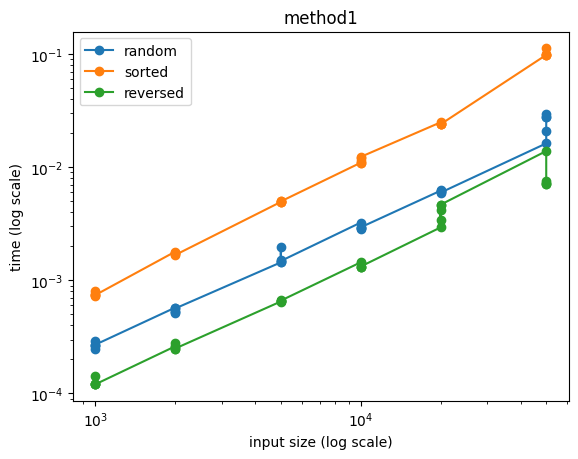

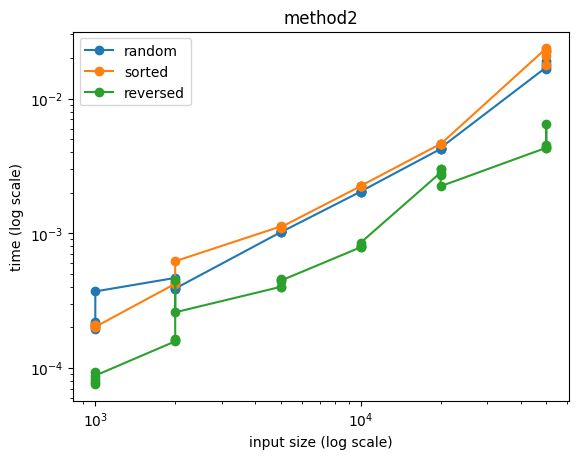

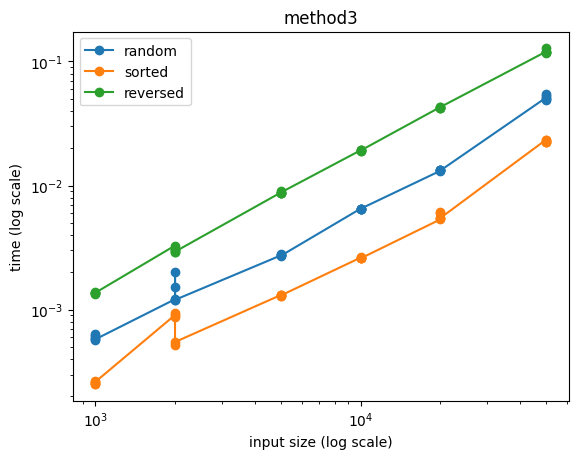

In [9]:
import matplotlib.pyplot as plt

for method in df["method"].unique():
    plt.figure()

    subset = df[df["method"] == method]

    for input_type in INPUT_TYPES:
        data = subset[subset["input"] == input_type]

        plt.plot(
            data["n"],
            data["time"],
            marker="o",
            label=input_type
        )

    plt.xscale("log")
    plt.yscale("log")
    plt.title(f"{method}")
    plt.xlabel("input size (log scale)")
    plt.ylabel("time (log scale)")
    plt.legend()
    plt.show()

### Regression Analysis

Method One:

In the best case, this algorithm is linear and would run at an Θ(n) time complexity.

Using regression analysis, the runtime could be represented as T(n) = an + b because sift_up would end right after it was called.

Since everything is constant time in the best case, each iteration costs the same constant amount T(n) = c1 + c2 + c3 + ... and the happens over n elements T(n) = cn + b.

This gives a Θ(n) time complexity.

Method Two:

This algorithm also takes Θ(n) time to run.

Using regression analysis, it can written using the linear model T(n) = an + b.

This is because the arr.copy() portion of the code takes O(n) time and the rest of the algorithm takes n/2 time to run. Sift down would be constant time in the best case as well.

That gives an expression that looks like this T(n) = c1n + c2(n/2) + b
which can simplifyed to T(n) = cn + b.

This gives a Θ(n) time complexity.

Method Three:

The best case run time of this algorithm is Θ(nlogn) which is the same as its worst case time complexity.

Using regression analysis the algorithm can be represented by the log-linear equation: T(n) = anlogn + b

This is because sift_up and sift_down are always called regardless of if this is the best or worst case. Since every now entry starts at the root and then moves down the heap, each insertion would take O(logn) time. The it has to do that n more times which gives O(nlogn).

### Summary of Findings

I thought it was interesting that model 1 and model 3 have similar graph results but flipped. Method 1 performs best with reversed data and worst with sorted data. Method 3 performs best with sorted data and worst with reversed data. Random data sits in the middle for both of them. Method 2 stands out from the rest a bit because the results are messier than methods 1 and 3, although it still performs best with reversed data in most cases. It seems that method 2 would be the best option if you didn't know what kind of data you had and either method 1 or 3 would be best if you knew what kind of data you had.

### Questions & Answers
Answer the following using your experimental evidence.

1. Does the empirically-determined runtime match the theoretic runtime? If not, what might have caused the discrepancy?

After looking at the graphs for each of the methods and comparing it to each methods theoretical run time, it does not seem to match in some cases. Method 1 and 3 are stated to be O(nlogn) time complexity while Method 2 is stated to be O(n). Taking a look at the graphs, they all appear to grow at a constant rate. Method 1 and 3 have graphs that look similar, the difference being the data the performs the best. Method 2 grows a bit more erratically. I suspect that the discrepancy comes from the way that these methods are actually executed by the system. The system might be doing things behind the scenes to speed up how the data processes, therefore changing how the methods time complexity looks.

2. Was there a noticeable difference between sorted, reverse-sorted, and random data? If so, describe and explain.

Yes, each method had different results for sorted, reverse sorted data.However, random data remained in the middle for each method, expect for some cases in method 2. Method 1 and 2 performed best with reverse sorted data and method 3 performed best with sorted data. Overall, the difference between each model were not extreme but each one shows a clear senario where it should be used over the others.

3. What runtime effect do you get by using heapify vs adding all elements to an empty heap? Explain.

When adding all the elements to the empty heap directly you would end up with O(nlogn) time but using heapify would give an O(n) time. This is because when adding directly elements may have to move all the way up or down the tree every time something is added, but heapify starts sorting at the bottom which is reduces the amount that each element has to move. Overall, heapify results in a faster time.

4. Compare bubbling down and stopping short to bubbling all the way down, then back up. When might each approach be better?

Bubbling down and stopping short is best when the heap is small or if you know the value should be in the upper half of the heap. If either of those things are true, stopping short can save time because the algorithm wont have to go all the way to the bottom and back up. Going all the way to the bottom and back is the best option when the heap is large or if you know the element is lower down in the tree/you don't know where it goes. If the element already needs to go lower down in the heap, stopping short would be a waste of time and it would be better to go all the way down and come back up.

### Appendix: Source Code & Test Cases
TODO